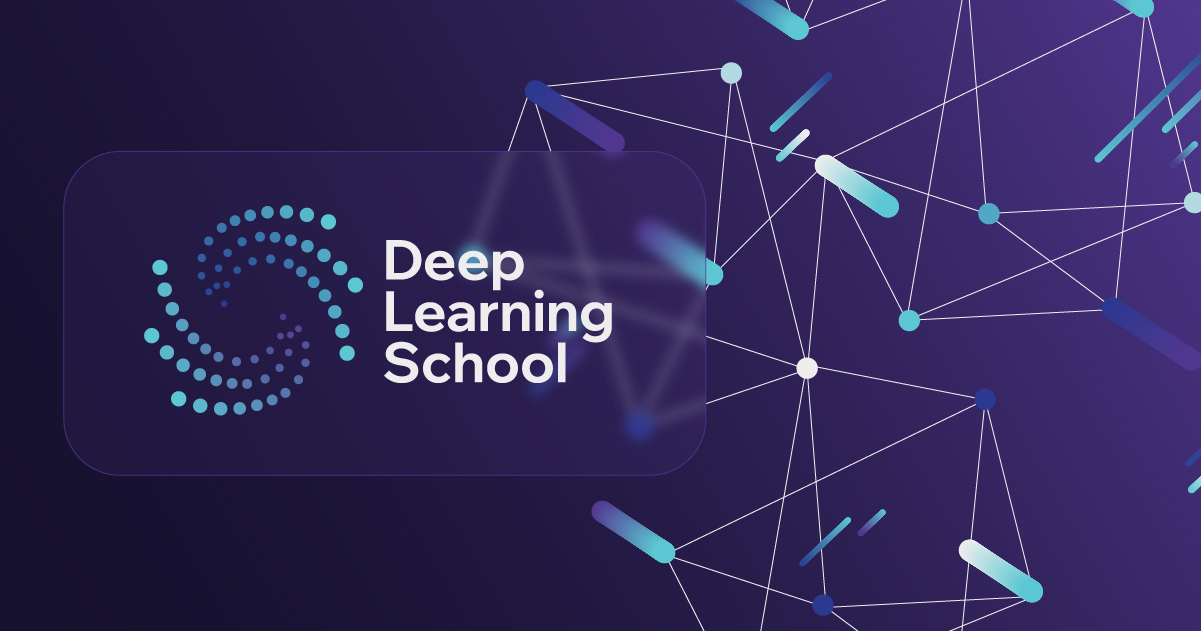


На семинаре было показано, как можно обучить классический GAN. Такая версия модели имеет множество недостатков, поэтому в этом домашнем задании вы модифицируете код с семинара, обучив более сложную модель **WGAN-GP** генерировать аниме-лица, а также посмотрите на то, как можно оценивать качество генерации.

За эту работу можно получить до 10 баллов. В заданиях есть ячейки, в которых вы должны будете написать ответ словами. Не пропускайте их, они тоже оцениваются.

In [1]:
import os

# os.environ["TORCH_USE_CUDA_DSA"] = "1"
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn.functional as F
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

from PIL import Image


import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

from torchinfo import summary

In [2]:
import os

def is_wsl():
    try:
        with open("/proc/version", "r") as f:
            return "microsoft" in f.read().lower()
    except FileNotFoundError:
        return False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
num_workers = 16 if is_wsl() else 0 # works ok via WSL only

print(f"DEVICE = {DEVICE}")
print(f"num_workers = {num_workers}")

torch.set_float32_matmul_precision('medium')

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

DEVICE = cuda
num_workers = 16


## Часть 1. Подготовка данных

### Загрузка датасета ~~Anime Face Dataset~~ Flickr Faces
#### Прошу простить мне вольность с подменой датасета на тот, что в варианте домашки с GAN - оч хочется сравнить WGAN-GP с GAN, который я попробовал обучить но пошло туго. Будем смотреть на реальных людей. А аниме в другой раз посмотрим.


~~Датасет [Anime Face Dataset](https://www.kaggle.com/datasets/splcher/animefacedataset) представляет собой набор из 63,632 "high-quality" изображений аниме лиц размером 63х63.~~

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)


Подготовим dataloader для обучения нашего будущего WGAN-GP

In [3]:
class FlickrFacesHqDataset(Dataset):
  def __init__(self, root, image_size=128):
    self.image_size = image_size

    self.transform = tt.Compose([
        # tt.Resize((image_size, image_size)), # я заранее пожал датасет отдельным скриптом, чтобы тут не было CPU bottleneck
        tt.ToTensor(),
        tt.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # тк tanh активация в генераторе будет давать такой выход [-1;1]
    ])

    self.paths = []
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                self.paths.append(os.path.join(dirpath, f))
    assert len(self.paths) > 0, f"No pictures found in {root}"

  def __len__(self):
      return len(self.paths)

  def __getitem__(self, idx):
    path = self.paths[idx]
    img = Image.open(path).convert('RGB')
    return self.transform(img)

def get_dataloader(image_size, batch_size) -> DataLoader:
  dataset = FlickrFacesHqDataset(root="ffhq_128", image_size=image_size)
  return DataLoader(
     dataset, 
     batch_size=batch_size, 
     shuffle=True, 
     pin_memory=True, 
     num_workers=num_workers, 
     persistent_workers=(num_workers > 0), 
     prefetch_factor=8
    )

Посмотрим, как выглядят наши изображения

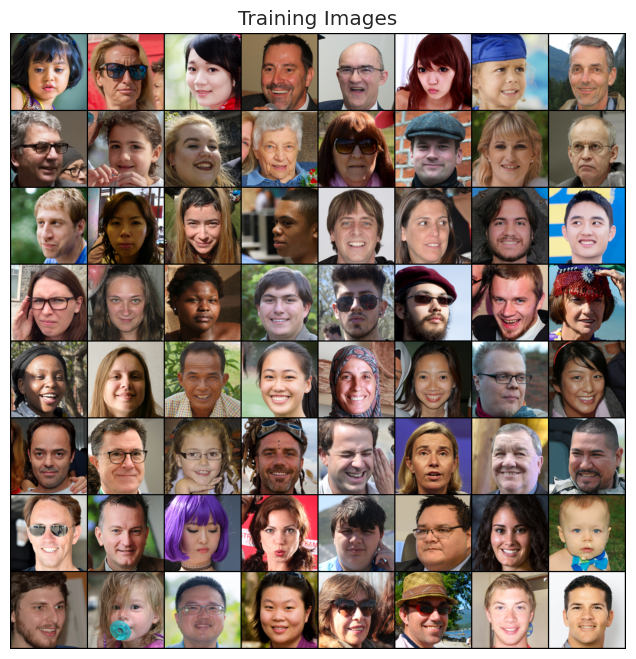

In [4]:
image_size = 128
dataloader = get_dataloader(image_size=image_size, batch_size=64)

import torchvision.utils as vutils

# Отрисовка изображений из датасета
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch.to(DEVICE)[:64], padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()

## Часть 2. Wasserstein GAN with Gradient Penalty: WGAN-GP (8 баллов)

### Проблемы классических GAN (теория)

Перед тем, как говорить про WGAN-GP, вспомним, какие были проблемы у классических GAN.



1.   **Vanishing gradients** — одна из главных проблем классических GAN, которая возникает в ситуации, когда дискриминатор становится слишком "сильным" и легко различает реальные и сгенерированные данные. В этом случае, градиенты генератора становятся слишком маленькими, что приводит к плохому обучению модели.

2.   **Mode collapse** — это проблема, при которой генератор начинает производить множество однотипных сэмплов, не используя всё разнообразие тренировочных данных, например, как показано на картинке ниже. Кстати, она сгенерирована той же архитетурой GAN, которая была показана на семинаре.

3. **Интерпретация лосса при обучении** - бинарная кросс-энтропия напрямую не измеряет расстояние между реальным и генерируемым распределениями, она лишь отражает способность дискриминатора различать реальные и фейковые данные. Если генератор производит плохие сэмплы, loss дискриминатора всё равно может уменьшаться, что создает ложное представление о прогрессе обучения.

<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1ShXxZqVD9cXZIuHzeW_tbO-StV-uxCy5" width=787 height=148/></p>



### Что такое WGAN-GP и как он решает проблемы классического GAN? (теория)

На самом деле, правильнее будет сказать, что WGAN-GP - это модификация WGAN, нежели классического GAN. То есть, мы пропустили один важный промежуточный этап. Однако с точки зрения реализации WGAN-GP не на много сложнее, чем WGAN. При этом результаты получаются лучше. Но начнем мы именно с этого промежуточного этапа - WGAN. Что же это такое и в чем отличие по сравнению с классическим GAN?

Первое, о чем стоит поговорить - это функция потерь. Дискриминатор классического GAN работает как бинарный классификатор, выдавая **вероятности** для реальных и фейковых данных на выходе. Поэтому в качестве функции потерь используется бинарная кросс-энтропия:

$L_{\text{discriminator}} = -\mathbb{E}_{x \sim p_{\text{data}}} [\log D(x)] - \mathbb{E}_{z \sim p_z} [\log(1 - D(G(z)))]$

$L_{\text{generator}} = -\mathbb{E}_{z \sim p_z} [\log D(G(z))]$


Именно здесь и кроятся основные проблемы GAN'ов, про которые мы говорили выше. Когда дискриминатор достигает идеальной точности ($D(x)\approx 1$ для реальных данных и $D(G(z))\approx 0$ для фейковых), производная лосса генератора $\mathbb{E}_{z \sim p_z} [\log D(G(z))]$ может стремиться к нулю (это не совсем тривиальное утверждение, но доказательство мы здесь опустим). Это приводит к тому, что генератор перестаёт получать полезные сигналы для обучения (vanishing gradients). Также, такой лосс не учитывает разнообразие тренировочных данных, и генератор может находить локальный оптимум, где он производит один или несколько типов данных, которые легко обманывают дискриминатор (mode-collapse).




Идея модификации заключается в отказе от бинарной кросс-энтропии. Вместо этого в модели WGAN используется Wasserstein-расстояние.

$W(p_{\text{data}}, p_{\text{gen}}) = \inf_{\gamma \in \Pi(p_{\text{data}}, p_{\text{gen}})} \mathbb{E}_{(x, y) \sim \gamma} [\|x - y\|]$

Да уж... формула выглядит страшновато, но, как очень часто бывает, на практике она нам не понадобится из-за сложности для прямого вычисления. При обучении WGAN используются следующие формулы:

$W(p_{\text{data}}, p_{\text{gen}}) = -L_{\text{critic}} = \sup_{\|C\|_L \leq 1} \left( \mathbb{E}_{x \sim p_{\text{data}}} [C(x)] - \mathbb{E}_{z \sim p_z} [C(G(z))] \right)$

$L_{\text{generator}} = -\mathbb{E}_{z \sim p_z} [C(G(z))]$

Скорее всего, вы заметили новое обозначение $C(x)$. В теории WGAN'ов таким образом обозначается то, что раньше мы называли дискриминатором $D(x)$. Теперь модель, которую пытается обмануть генератор, называется **"Критик" ("Critic")**. Главное отличие критика от дискриминатора заключается в том, что критик - не бинарный классификатор. **На выходе у критика не вероятности, а некоторая численная оценка**, для которой при обучении подсчитывается Wasserstein-расстояние. Также, в процессе обучения происходит клиппирование весов критика $\|C\|_L \leq 1$, чтобы сохранить его липшевость (подробнее об этом чуть позже). **Во всем остальном критик и дискриминатор идентичны**.

Такой подход позволяет успешно бороться с проблемами классических GAN:

1.   **Mode-collapse**: Wasserstein-дистанция учитывает всю структуру распределений, что побуждает генератор создавать разнообразные образцы.
2.   **Vanishing gradients**:
Генератор всегда получает полезные сигналы для обучения, даже если он находится далеко от целевого распределения.
3. **Интерпретация лосса при обучении**: Wasserstein-дистанция является более естественной метрикой для сравнения распределений, чем бинарная кросс-энтропия. Она напрямую показывает, насколько одно распределение отличается от другого, поэтому в процессе обучения лосс должен монотонно уменьшаться.






Подведем итоги

|               | **Классический GAN**                          | **WGAN**                                    |
|--------------------------|-----------------------------------------------|------------------------------------------------|
| **Функция потерь**       | Бинарная кросс-энтропия                       | Wasserstein-дистанция      |
| **Выход модели**         | Вероятность \($ D(x) \in [0, 1] $ \)          | Скалярное значение \($ C(x) \in \mathbb{R} $\) |                           |
| **Стабильность обучения**| Нестабильное обучение                         | Гораздо более стабильное обучение               |
| **Mode collapse**         | Часто встречается                             | Реже встречается                               |
| **Поведение градиентов**     | Исчезающие градиенты (vanishing gradients)     | Постоянные и значимые градиенты                 |
| **Интерпретируемость**      | Loss сложно интерпретировать                   | Loss монотонно уменьшается                     |

Более подробно и математически строго про WGAN можно почитать в [оригинальной статье](https://arxiv.org/pdf/1701.07875).

### Построение модели (2 балла)

Сконструируйте модели генератора и критика. В этом задании подразумевается, что за основу вы возьмете код с семинара, однако при желании вы можете экспериментировать. Главное - помните, что критик на выходе выдает не вероятности, а просто некоторые **скалярные значения**, во всем остальном модели могут быть идентичными.

In [5]:
class PixelNorm(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(dim=1, keepdim=True) + self.eps)

def weights_init_norm(m, mean=0.0, std=0.02):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight, mean=mean, std=std)
        if m.bias is not None:
            nn.init.zeros_(m.bias)



class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail_activation = True):
        super(DecoderBlock, self).__init__() 
        
        UPSCALE_FACTOR = 2 
        self.upsampling = nn.Sequential( 
            nn.Conv2d(in_channels, out_channels * (UPSCALE_FACTOR ** 2), kernel_size, padding=1), 
            nn.PixelShuffle(UPSCALE_FACTOR), 
            nn.LeakyReLU(inplace=True, negative_slope=0.2), 
        )

        self.layers = nn.Sequential()

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.LeakyReLU(inplace=True, negative_slope=0.2))

        self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        
        if tail_activation:
            self.layers.append(nn.LeakyReLU(inplace=True, negative_slope=0.2))

    def forward(self, x):
        x = self.upsampling(x)
        x = self.layers(x)
        
        return x

class Generator(nn.Module):
    def __init__(self, latent_size, conv_channels, conv_depth, image_size, min_square, kernel_size=3):
        super(Generator, self).__init__()

        RGB_CHANNELS = 3
        assert image_size in [16, 32, 64, 128, 256, 512, 1024, 2048], "Only 2^N image sizes in range [16; 2048] are allowed"

        self.decoder = nn.Sequential(
            nn.Linear(in_features=latent_size, out_features=min_square * min_square * conv_channels),
            nn.Unflatten(dim=1, unflattened_size=(conv_channels, min_square, min_square)),
        )

        # Динамически добавляем апсемплы до нужного размера изображения
        decoded_image_size = min_square
        cur_channels = conv_channels
        is_last = False
        while decoded_image_size < image_size:
            is_last = (decoded_image_size * 2 >= image_size)
            self.decoder.add_module(
                f'upsample_{decoded_image_size}',
                DecoderBlock(
                    in_channels=cur_channels, 
                    out_channels=RGB_CHANNELS if is_last else cur_channels // 2, 
                    depth=conv_depth,
                    kernel_size=kernel_size,
                    padding=kernel_size // 2,
                    tail_activation=not is_last
                ),
            )
            decoded_image_size *= 2
            cur_channels //= 2
            assert cur_channels > RGB_CHANNELS, f"conv_channels = {conv_channels} is too small for target image size {image_size}"

        assert is_last, "Last convolution should be added"

        self.apply(weights_init_norm)

    def forward(self, x):
        x = self.decoder(x)
        x = torch.tanh(x)
        return x

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.LeakyReLU(inplace=True, negative_slope=0.2))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.LeakyReLU(inplace=True, negative_slope=0.2))

        self.downsampling = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=padding)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.downsampling(x)
        return x

class Critic(nn.Module):
    def __init__(self, conv_channels, conv_depth, image_size, min_square, kernel_size=3):
        super(Critic, self).__init__()
        
        assert image_size in [16, 32, 64, 128, 256, 512, 1024, 2048], "Only 2^N image sizes in range [16; 2048] are allowed"

        self.backbone = nn.Sequential()

        downsampled_size = image_size
        num_downsamples = int(np.log2(image_size // min_square))
        curr_channels = conv_channels // (2**num_downsamples)
        while downsampled_size >= min_square * 2:
            curr_channels *= 2
            self.backbone.add_module(
                f'downsample_{downsampled_size}',
                EncoderBlock(
                    in_channels=3 if downsampled_size == image_size else curr_channels // 2, 
                    out_channels=curr_channels, 
                    depth=conv_depth,
                    kernel_size=kernel_size,
                ),
            )
            downsampled_size //= 2
            
        
        self.head = nn.Conv2d(
            in_channels = curr_channels,
            out_channels = 1,
            kernel_size = min_square,
            stride = 1,
            padding = 0
        )

        self.apply(weights_init_norm)
    

    def forward(self, x, return_embedding=False):
        x = self.backbone(x)

        if return_embedding:
            return x.view(x.size(0), -1)

        score = self.head(x)
        score = score.view(score.size(0))

        return score

### Градиентный штраф (Gradient Penalty) и WGAN-GP (теория)

В WGAN критик $C(x)$ должен быть липшицевой функцией , то есть его производная должна быть ограничена:

$\|\nabla_{\hat{x}} C(\hat{x})\|_2 \leq 1$

Это требование необходимо для корректного вычисления Wasserstein-дистанции.

В оригинальном WGAN для обеспечения Липшицевости применяется клиппирование весов:

$w \in \[-c, c]\$,

где $w$ - параметры критика, а $c$ - некоторое маленькое число.

Однако такой подход слишком жестко ограничивает диапозон значений весов, что часто приводит к нестабильности обучения и плохой сходимости.

Альтернативой клиппирования является **градиентный штраф (Gradient Penalty)**, который представляет собой метод регуляризации весов, и добавляется в функцию потерь критика с некоторым коэффициентом $\lambda$:

$L_{\text{critic}} = -\mathbb{E}_{x \sim p_{\text{data}}} [C(x)] + \mathbb{E}_{z \sim p_z} [C(G(z))] + \lambda L_{\text{GP}}$

$L_{\text{GP}} = \mathbb{E}_{\hat{x} \sim P_{\hat{x}}} \left[ (\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1)^2 \right]$





**Как это работает?**


1) Создается интерполяция между реальными ($x_{real}$) и фейковыми ($x_{fake}$) данными

$\hat{x} = \alpha x_{\text{real}} + (1 - \alpha) x_{\text{fake}}$,

где $\alpha$ сэмплируется из равномерного распределения $\alpha \sim U(0, 1).$

2) Вычисляется норма градиента критика по интерполированным данным:

$\|\nabla_{\hat{x}} C(\hat{x})\|_2$

3) Добавляется штраф за отклонение нормы градиента от 1 и усредняется по всем интерполированным точкам

$L_{\text{GP}} = \mathbb{E}_{\hat{x} \sim P_{\hat{x}}} \left[ (\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1)^2 \right]$

Более подробно о градиентном штрафе можно почитать в [оригинальной статье](https://arxiv.org/pdf/1704.00028).

### Напишите функцию для вычисления градиентного штрафа $L_{\text{GP}}$ (2 балла)

In [6]:
def compute_gradient_penalty(critic, real_samples, fake_samples, lambda_gp, device):
    """
    Вычисляет градиентный штраф для WGAN-GP.

    :param critic: Модель критика.
    :param real_samples: Тензор с реальными изображениями.
    :param fake_samples: Тензор с фейковыми изображениями.
    :param device: Устройство для вычислений CPU/GPU.
    :return: Градиентный штраф
    """

    # Создание интерполированных данных, используйте torch.rand для сэмплирования alpha
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device)
    x_hat = alpha * real_samples + (1 - alpha) * fake_samples
    x_hat = x_hat.requires_grad_(True)

    # Вычисление выхода критика для интерполированных данных
    critic_interpolates = critic(x_hat)

    # Подготовка градиентов
    grad_outputs = torch.ones_like(critic_interpolates, device=device)

    # Вычисление градиента по интерполированным данным
    gradients = torch.autograd.grad(
        outputs = critic_interpolates,
        inputs = x_hat,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    # Вычисление нормы градиента
    gradients = gradients.view(gradients.size(0), -1)
    gradient_norm = gradients.norm(2, dim=1)

    # Вычисление градиентного штрафа (мат ожидание = усреднение)
    # штрафуем, если он начинает нарушать ограничение по Липшицу
    gradient_penalty = lambda_gp * ((gradient_norm - 1) ** 2).mean()

    return gradient_penalty

### Напишите функцию для обучения WGAN-GP (2 балла)

Ваша задача - реализовать процесс обучения WGAN-GP. По своей структуре он не сильно отличается от того, что было показано на семинаре для классических GAN. В первую очередь, вам нужно правильно прописать все лоссы:

$L_{\text{critic}} = -\mathbb{E}_{x \sim p_{\text{data}}} [C(x)] + \mathbb{E}_{z \sim p_z} [C(G(z))] + \lambda L_{\text{GP}}$

$L_{\text{GP}} = \mathbb{E}_{\hat{x} \sim P_{\hat{x}}} \left[ (\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1)^2 \right]$

$L_{\text{generator}} = -\mathbb{E}_{z \sim p_z} [C(G(z))]$



Помимо этого, вам нужно будет реализовать еще одну хитрость, которую советуют авторы статей. Веса генератора должны обновляться реже, чем веса критика. За это отвечает параметр $n_{critic}$. **Через критика градиенты должны протекать на каждом батче, а через генератор только на каждом кратном $n_{critic}$ батче**. Это позволяется добиться лучшего баланса между критиком и генератором.

Итоговый алгоритм обучения выглядит следующим образом:



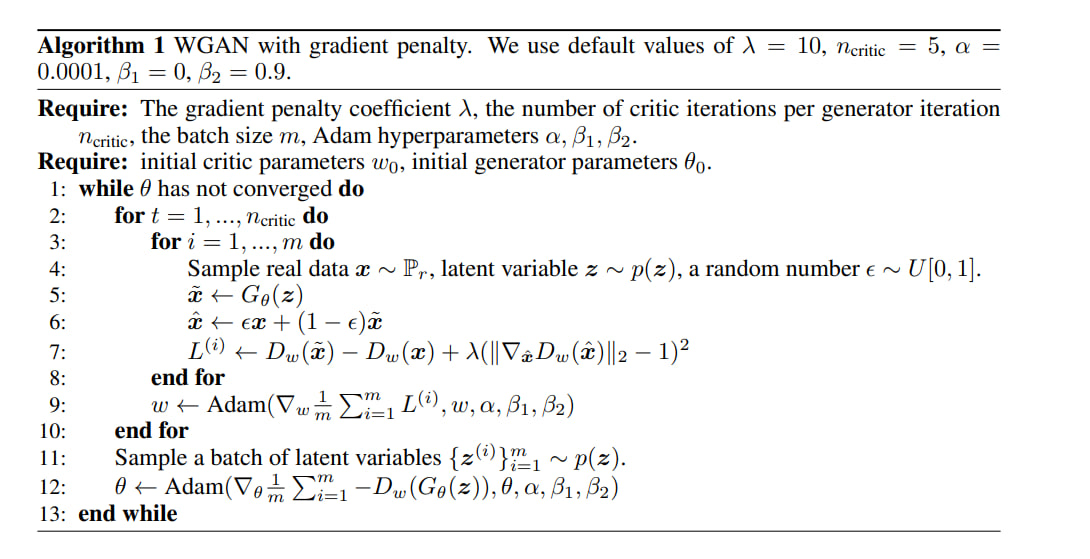

За подробностями предлагается обратиться к статьям: [WGAN](https://arxiv.org/pdf/1701.07875), [WGAN-GP](https://arxiv.org/pdf/1704.00028).


In [7]:
class LitWGanModel(L.LightningModule):

    def __init__(self, conv_channels, conv_depth, latent_dim, img_size,
                 critic_steps=3, lambda_gp=10, min_square_gen=4, min_square_crit=4,
                 conv_channels_critic=64, conv_depth_critic=1,
                 lr_gen = 1e-4, lr_dis = 1e-4):
        super().__init__()

        self.lr_gen = lr_gen
        self.lr_dis = lr_dis

        self.save_hyperparameters()
        
        self.automatic_optimization = False

        # дискриминатор будет делать N шагов за 1 шаг генератора
        self.critic_steps = critic_steps
        self.lambda_gp = lambda_gp
        
        self.generator = Generator(
            latent_size=latent_dim, 
            conv_channels=conv_channels, 
            conv_depth=conv_depth, 
            image_size=image_size, 
            min_square=min_square_gen
        )
        self.generator = torch.compile(self.generator)
        self.critic = Critic(
            conv_channels=conv_channels_critic, 
            conv_depth=conv_depth_critic, 
            image_size=image_size, 
            min_square=min_square_crit
        )

        self.latent_dim = latent_dim
        self.img_size = img_size

    def forward(self, x):
        return self.generator(x)

    def configure_optimizers(self):
        opt_dis = torch.optim.Adam(lr=self.lr_dis, betas=(0.0, 0.9), params=self.critic.parameters())
        opt_gen = torch.optim.Adam(lr=self.lr_gen, betas=(0.0, 0.9), params=self.generator.parameters())
        
        return [opt_dis, opt_gen], []
    

    def train_generator(self, real, optimizer):
        z = torch.randn(real.size(0), self.latent_dim, device=self.device)
        generated = self.generator(z)
        assert generated.shape[2] == self.img_size, f"Generated image size {generated.shape[2]} should be equal to the image size {self.img_size}"

        scores_fake = self.critic(generated)
        loss = -scores_fake.mean()

        self.log("generator_train_loss", loss, on_epoch=True, prog_bar=True)
        
        optimizer.zero_grad()
        self.manual_backward(loss)
        optimizer.step()


    def train_critic(self, real, optimizer):
        scores_real = self.critic(real)
        
        z = torch.randn(real.size(0), self.latent_dim, device=self.device)
        generated = self.generator(z).detach()
        assert generated.shape[2] == self.img_size, f"Generated image size {generated.shape[2]} should be equal to the image size {self.img_size}"
        scores_fake = self.critic(generated)
        
        gp = compute_gradient_penalty(
            critic = self.critic,
            real_samples = real,
            fake_samples = generated,
            lambda_gp = self.lambda_gp,
            device = self.device
        )

        fake_mean = scores_fake.mean()
        real_mean = scores_real.mean()
        wasserstein_gap = fake_mean - real_mean
        loss = wasserstein_gap + gp
        
        self.log("critic_wasserstein_gap", wasserstein_gap, on_step=True, on_epoch=True)
        self.log("critic_wasserstein_distance", real_mean - fake_mean, on_step=True, on_epoch=True)

        self.log("critic_gradient_penalty", gp, on_epoch=True)
        self.log("critic_loss", loss, on_epoch=True)
        
        optimizer.zero_grad()
        self.manual_backward(loss)
        optimizer.step()


    def training_step(self, batch, batch_idx):
        opt_discr, opt_gen = self.optimizers() 

        for _ in range(self.critic_steps):
            self.train_critic(batch, optimizer=opt_discr)
        
        self.train_generator(batch, optimizer=opt_gen)

In [8]:
class ImageLoggerCallback(L.Callback):
    def __init__(self, fixed_z, log_every_n_epochs=1, log_every_n_steps=-1, img_dir="logs/images", nrow=16):
        self.log_every_n_epochs = log_every_n_epochs
        self.log_every_n_steps = log_every_n_steps
        self.fixed_z = fixed_z
        self.img_dir = img_dir
        self.nrow = nrow
        os.makedirs(img_dir, exist_ok=True)

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch
        if self.log_every_n_epochs > 0 and epoch % self.log_every_n_epochs == 0:
            self.log_images(pl_module, epoch)


    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        if self.log_every_n_steps > 0 and batch_idx % self.log_every_n_steps == 0:
            self.log_images(pl_module, trainer.current_epoch * trainer.num_training_batches + batch_idx)

    def log_images(self, pl_module, step):
        pl_module.generator.eval()
        with torch.no_grad():
            z = self.fixed_z.to(pl_module.device)
            generated = pl_module.generator(z).cpu()
        pl_module.generator.train()

        grid = make_grid(generated, nrow=self.nrow)

        pl_module.logger.experiment.add_image("Generated", grid, global_step=step)
        save_image(grid, os.path.join(self.img_dir, f"{step:05d}.png"))

### Обучение WGAN-GP (2 балла)

С параметрами обучения можете поэкспериментировать или взять стандартные из статьи.



In [9]:
image_size = 128
batch_size=120

latent_size = 256

conv_channels=1024
conv_depth=1

critic_steps=5

conv_channels_critic=512
conv_depth_critic=1

min_square_crit=8
min_square_gen=8

lr_gen = 1e-4
lr_dis = 1e-4

In [ ]:
lit_model = LitWGanModel(
    latent_dim=latent_size, 
    img_size=image_size,
    conv_channels=conv_channels,
    conv_depth=conv_depth,
    conv_channels_critic=conv_channels_critic,
    conv_depth_critic=conv_depth_critic,
    critic_steps=critic_steps,
    min_square_crit=min_square_crit,
    min_square_gen=min_square_gen
).to(DEVICE)

summary(lit_model.critic, input_size=(1,3,image_size,image_size))
summary(lit_model.generator, input_size=(1,latent_size))

MODEL_NAME = "WGAN"
EXP_VERSION = 24
EXP_COMMENT = f"v{EXP_VERSION}_ffhq"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{MODEL_NAME}/{EXP_COMMENT}",
    filename=f"{MODEL_NAME}-{{epoch:03d}}",
    every_n_epochs=10,
    save_top_k=-1,
)

logger_cb = ImageLoggerCallback(
    log_every_n_epochs=3, 
    log_every_n_steps=0, 
    fixed_z = torch.randn(size=(4*2, latent_size)), 
    img_dir=f"./lightning_logs/{MODEL_NAME}/{EXP_COMMENT}/img",
    nrow=4
)

trainer = L.Trainer(
    max_epochs=200,
    logger = TensorBoardLogger("lightning_logs", name=MODEL_NAME, version=EXP_COMMENT),
    log_every_n_steps=5,
    callbacks=[checkpoint_cb, logger_cb],
)

dataloader = get_dataloader(image_size=image_size, batch_size=batch_size)
trainer.fit(lit_model, dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


### Графики лоссов

Отрисуйте лоссы. Что вы можете сказать про полученные графики? Согласуются ли они с теорией?


**Loss критика:**

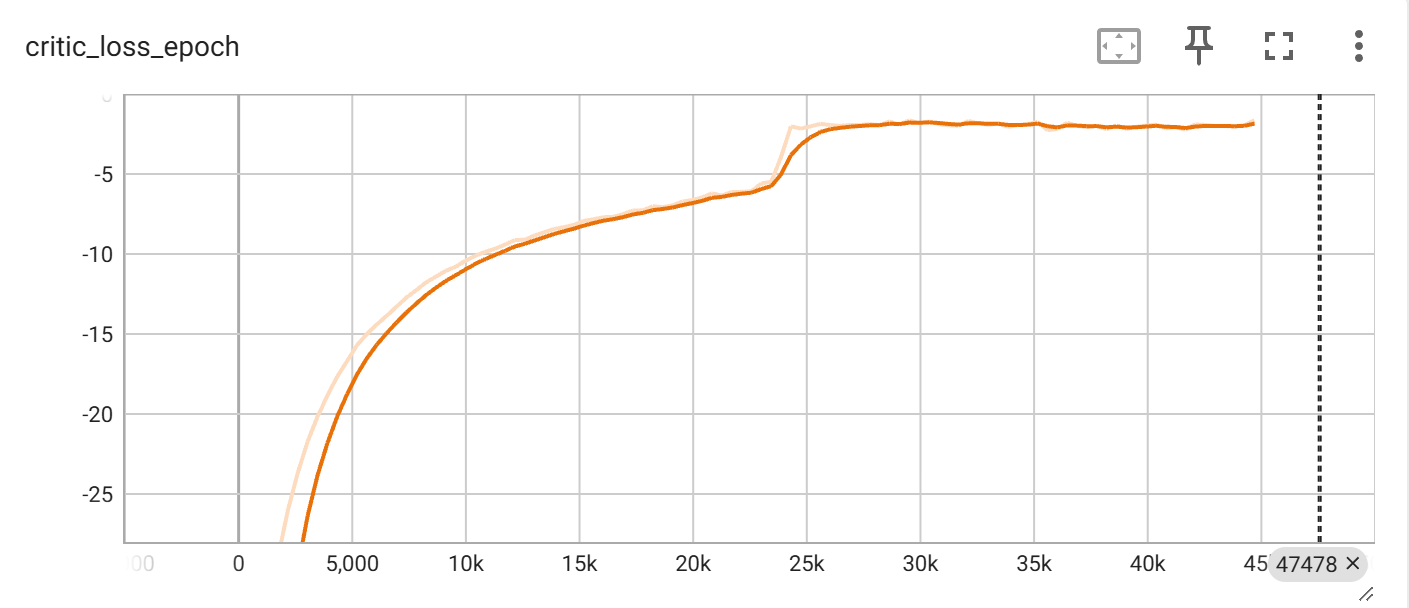

**Компонент Gradient Penalty:**

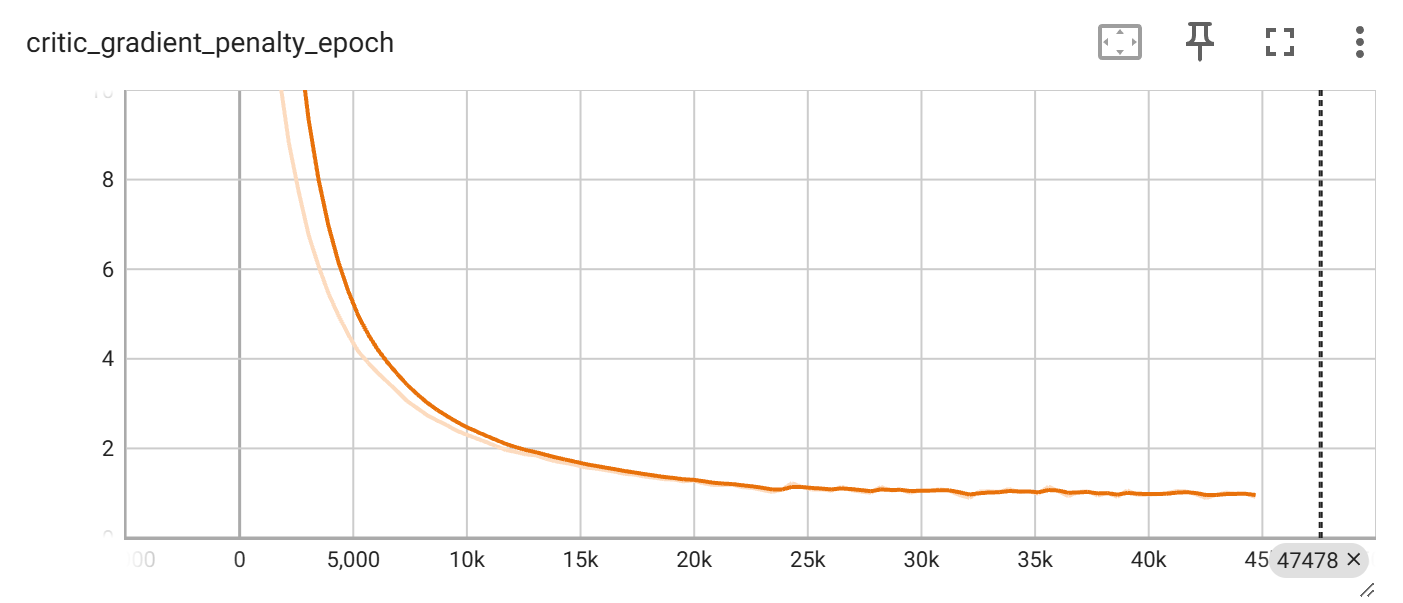

Loss критика в отрицательной области, выходит на плато чуть ниже нуля. Мне лично сложно для себя интерпретировать такой лосс в отрицательной области, потому что это выбивается из концепции "чем меньше loss тем ближе к идеальной модели". В этой архитектуре loss просто нужен для вычисления градиента, а числовое значение само по себе ни о чем особо и не говорит. 

Можно сказать, что **с теорией согласуется:**
- Gradient penalty стабилизируется в районе 1 и сильно не влияет. 
- Основным компонентом лосса критика остается wasserstein distance между реальным и генерацией - а этот компонент уменьшается, пока генератор способен улучшать близость к реальным фото.


**Loss генератора:**

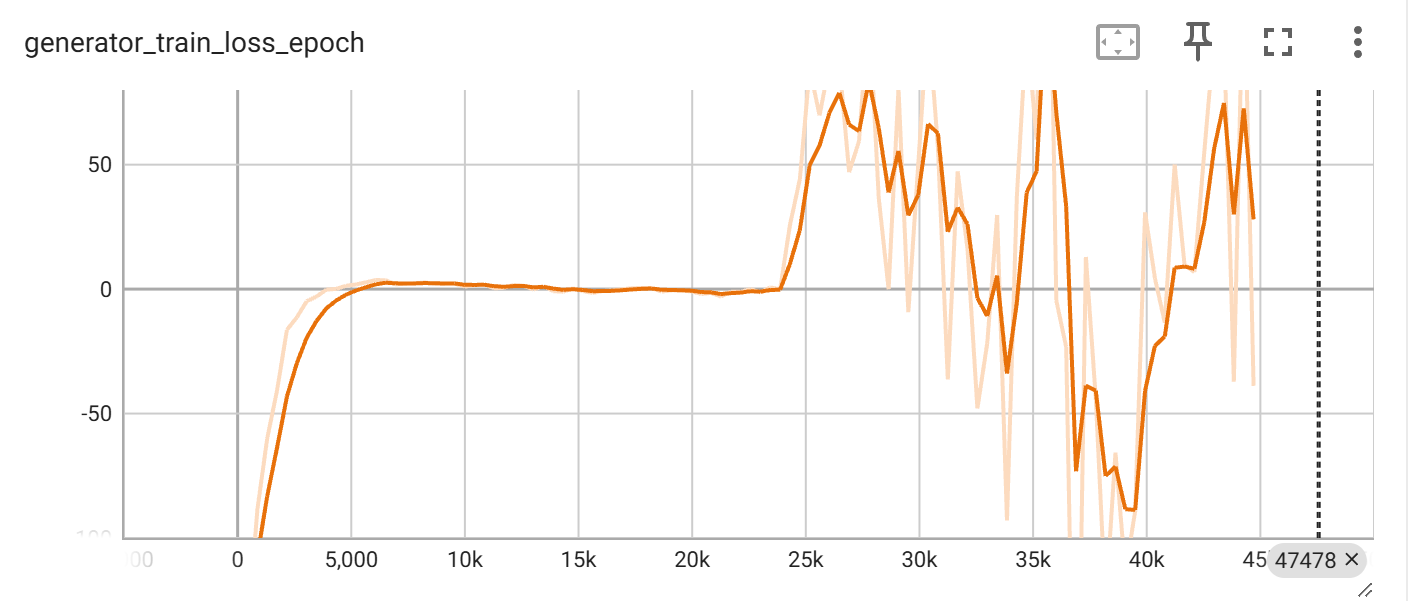

Loss генератора достаточно быстро выходит к нулю и колеблется в его окрестностях, и через много эпох в таком состоянии взрывается. То что колеблется в окрестностях нуля - ок, значит выход генератора по распределению приблизился к реальным фото, критик не видит большой разницы, генератор далее не знает куда улучшаться. Возможно, при более сильном критике можно было бы получить лучшие результаты. 

А взрыв лосса можно объяснить слишком долгим обучением, слишком долго в районе нуля колебался и на каком-то неудачном батче случайно шагнул по градиенту в неудачную сторону и дестабилизировался. Визуально также видно, что в этот момент картинкам становится сильно хуже. Поэтому далее в качестве лучшей модели берется модель с эпохи до этого взрыва.

### Отрисовка генераций после обучения

Что вы можете сказать о качестве полученных изображений?

In [11]:
import math

def show_images(generated, rows=None, cols=None):
    n = len(generated)
    
    if rows is None or cols is None:
        cols = math.ceil(math.sqrt(n))
        rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    axes = axes.flatten() 
    
    for i, tensor in enumerate(generated):
        ax = axes[i]
        tensor = tensor.detach().cpu()
        tensor_img = (tensor + 1) / 2
        tensor_img = tensor_img.clamp(0, 1)
        tensor_img = tensor_img.permute(1, 2, 0)
        ax.imshow(tensor_img)
        ax.axis("off")
    
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    
    plt.show()


In [12]:
best_wgan = LitWGanModel.load_from_checkpoint(
    'checkpoints/WGAN/v24_ffhq/WGAN-epoch=049.ckpt',
    map_location=DEVICE,
)

/home/eplotnikov/projects/DeepLearningSchool_part_1_ml_cv/venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


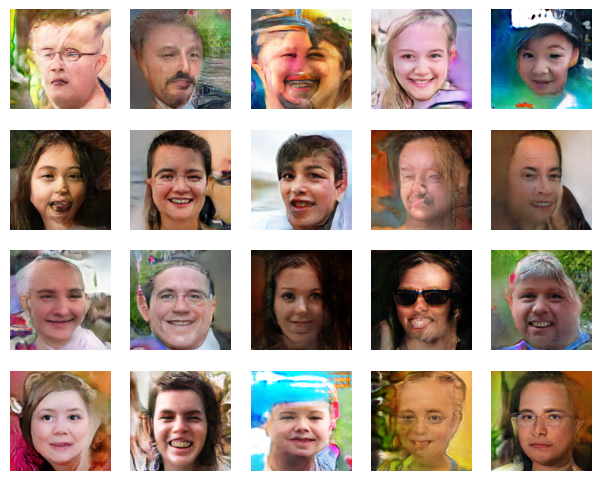

In [ ]:
n_images = 20

fixed_latent = torch.randn(n_images, latent_size, device=DEVICE)
best_wgan.generator.eval()
fake_images = best_wgan.generator(fixed_latent)

show_images(fake_images)

**Что можно сказать про качество генерации:**
- На уровне периферийного зрения, если не разглядывать - обмануться можно
- Цвета плюс-минус адекватные, оттенки кожи реалистичные, зеленых лиц нет, максимум мужик сверху по центру слишком долго на пляже загорал
- Не произошло mode collapse - лица все разные, цвет кожи различается, пол, возраст - вариативно
- Сами лица в половине случаев весьма адекватные, нет третьего глаза, нос на месте, итд
- На границе лица и фона происходит жесть, причина понятна - фон за людьми на реальных фото гораздо более вариативен, чем сами лица, там могут быть абсолютно любые объекты, и модель просто не может выучить такое распределение на малом датасете, и просто рисует "что-нибудь"


## Часть 3. Способы оценки качества генераций (2 балла)

### Подсчет accuracy (1 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (**sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)**) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет [sklearn.model_selection.LeaveOneOut](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html).

Такой способ оценки достаточно долгий, поэтому возьмите только часть изображений. Например, 500 реальных картинок и 500 фейковых.

In [18]:
num_images = 500

In [19]:
generator = best_wgan.generator

# Генерация изображений
generator.eval()
z = torch.ones(num_images, best_wgan.latent_dim).to(DEVICE)
with torch.no_grad():
    fake_images = generator(z)

In [20]:
# Подготовка реальных изображений
real_images = torch.tensor([])
dataloader = get_dataloader(image_size=image_size, batch_size=batch_size)
for batch in dataloader:
    real_images = torch.cat([real_images, batch], dim=0)
    if len(real_images) >= num_images:
        break
real_images = real_images.to(DEVICE)

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

critic = best_wgan.critic

real_embeddings = critic.forward(real_images, return_embedding=True).detach().cpu()
fake_embeddings = critic.forward(fake_images, return_embedding=True).detach().cpu()

embeddings = torch.cat([real_embeddings, fake_embeddings], dim=0)
labels = torch.cat([torch.ones(real_embeddings.shape[0]), torch.zeros(fake_embeddings.shape[0])], dim=0)

leave1 = LeaveOneOut()
y_true = []
y_pred = []

for train_idx, test_idx in leave1.split(embeddings):
    X_train, X_test = embeddings[train_idx], embeddings[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train, y_train)
 
    score = knn.predict(X_test)

    y_true.append(y_test[0])
    y_pred.append(score[0])

acc = accuracy_score(y_true, y_pred)
print(acc)

0.9990909090909091


Посчиталась почти единица. Непонятно, как это лучше поможет оценить качество генерации. Возможно, при более сильном критике это имеет смысл, но т.к в моем случае wasserstein distance сошелся почти к нулю - критик уже не может различить реальность и генерацию. 

Концептуально получается странная ситуация, когда оценка качества модели зависит от архитектуры самой модели, модель сама оценивает свое качество, и чем хуже модель - тем хуже она же оценит свое качество. Я бы сказал, что все-таки либо оценивать на глаз - лучший путь, либо для оценки надо использовать какую-то внешнюю более мощную модель "с репутацией", а не свою экспериментальную.

### Визуализация распределений (1 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

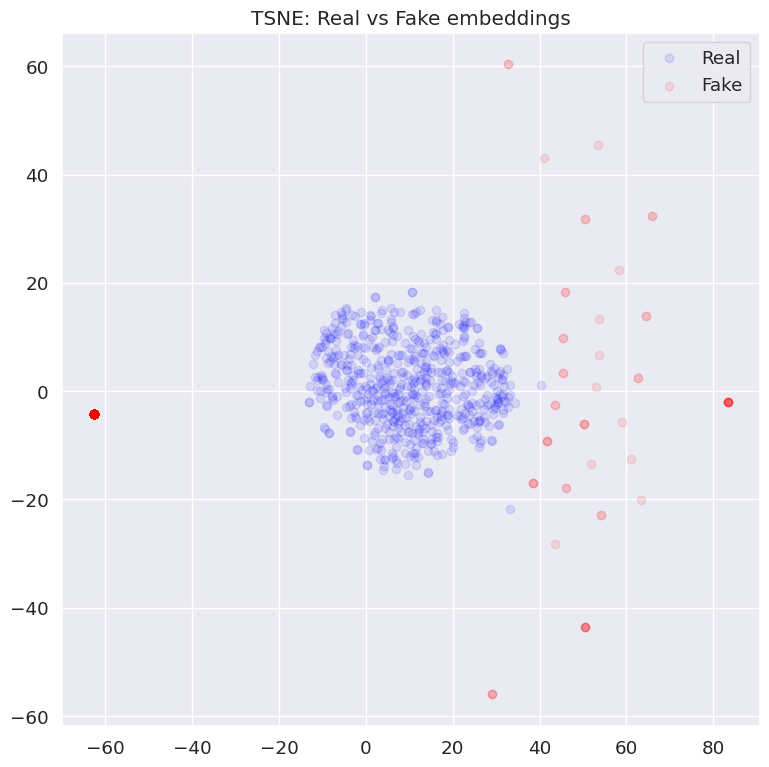

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=20, random_state=43)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(9, 9))
plt.scatter(emb_2d[labels==1, 0], emb_2d[labels==1, 1], c='blue', label='Real', alpha=0.1)
plt.scatter(emb_2d[labels==0, 0], emb_2d[labels==0, 1], c='red', label='Fake', alpha=0.1)
plt.legend()
plt.title("TSNE: Real vs Fake embeddings")
plt.show()

Прокомментируйте получившийся результат:

Видно, что реальные изображения образуют облако понятной формы с очерченными границами. А сгенерированные сгруппированы очень странно - есть выраженные уплотнения (где красные точки наслаиваются друг на друга и выглядят ярко). Учитывая настолько сильную разницу в таком представлении, можно сказать что генерации далеки от идеальных. И возникают мысли, что TSNE можно использовать не только для визуальной оценки, но и как числовую метрику качества.